In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()

In [2]:
filtered_df = df[df["Type_of_vehicle"].isin(["motorcycle", "scooter"])]

filtered_df = filtered_df[
    (filtered_df["Restaurant_latitude"] != 0.0) &
    (filtered_df["Restaurant_longitude"] != 0.0) &
    (filtered_df["Delivery_location_latitude"] != 0.0) &
    (filtered_df["Delivery_location_longitude"] != 0.0)
    ]

filtered_df["Order_Date"] = pd.to_datetime(filtered_df["Order_Date"])

C:\Users\upeks\AppData\Local\Temp\ipykernel_13408\1928365070.py:10: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  filtered_df["Order_Date"] = pd.to_datetime(filtered_df["Order_Date"])


In [3]:
temp_df = filtered_df[["Restaurant_latitude", "Restaurant_longitude"]].groupby(["Restaurant_latitude", "Restaurant_longitude"]).size()
temp_df = temp_df.reset_index(name="Count")
temp_df = temp_df.sort_values(by="Count", ascending=False)
temp_df

,Restaurant_latitude,Restaurant_longitude,Count
603,26.911378,75.789034,175
598,26.902908,75.792934,164
479,22.308096,73.167753,162
594,26.888420,75.800689,162
596,26.892312,75.806896,162
...,...,...,...
235,-12.326356,-76.619103,1
236,-12.325461,-76.632278,1
237,-12.323994,-76.626167,1
238,-12.323225,-76.630028,1


In [4]:
filtered_df = filtered_df[(filtered_df["Restaurant_latitude"] == 26.911378) &
                          (filtered_df["Restaurant_longitude"] == 75.789034)
                          ]
filtered_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
193,0x7085,JAPRES09DEL01,21,4.7,26.911378,75.789034,26.921378,75.799034,2022-03-03,09:00:00,09:10:00,conditions Sunny,Low,0,Meal,motorcycle,1,No,Metropolitian,(min) 16
636,0x5d7a,JAPRES09DEL01,20,5,26.911378,75.789034,26.981378,75.859034,2022-03-18,19:00:00,19:15:00,conditions Sunny,Medium,0,Snack,motorcycle,1,No,Metropolitian,(min) 22
652,0x25eb,JAPRES09DEL03,23,4.7,26.911378,75.789034,27.051378,75.929034,2022-03-14,21:00:00,21:10:00,conditions Fog,Jam,0,Snack,motorcycle,1,No,Metropolitian,(min) 42
1007,0x5176,JAPRES09DEL01,21,4.6,26.911378,75.789034,26.951378,75.829034,2022-04-01,16:15:00,16:30:00,conditions Sandstorms,Medium,0,Drinks,motorcycle,0,No,Metropolitian,(min) 11
1070,0x68ba,JAPRES09DEL03,39,4.8,26.911378,75.789034,26.941378,75.819034,2022-03-09,17:15:00,17:30:00,conditions Stormy,Medium,2,Buffet,scooter,1,No,Urban,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44673,0x33d8,JAPRES09DEL02,37,4.6,26.911378,75.789034,26.961378,75.839034,2022-03-26,22:30:00,22:40:00,conditions Cloudy,Low,0,Meal,motorcycle,1,No,NaN,(min) 23
44752,0x7fb3,JAPRES09DEL01,22,4.8,26.911378,75.789034,26.951378,75.829034,2022-03-01,12:20:00,12:30:00,conditions Stormy,High,2,Snack,scooter,0,No,Metropolitian,(min) 15
44971,0x6eff,JAPRES09DEL01,39,5,26.911378,75.789034,27.021378,75.899034,2022-03-18,20:35:00,20:40:00,conditions Cloudy,Jam,2,Meal,scooter,2,No,Metropolitian,(min) 44
45148,0xb9ce,JAPRES09DEL03,23,4.8,26.911378,75.789034,26.941378,75.819034,2022-03-05,23:40:00,23:45:00,conditions Fog,Low,2,Drinks,scooter,1,No,Urban,(min) 11


In [5]:
lstm_df = filtered_df[["Order_Date"]].groupby(["Order_Date"]).size().reset_index(name="Num_Of_Orders").sort_values(by="Order_Date")
lstm_df

,Order_Date,Num_Of_Orders
0,2022-03-01,6
1,2022-03-02,5
2,2022-03-03,5
3,2022-03-04,5
4,2022-03-05,5
5,2022-03-06,4
6,2022-03-07,6
7,2022-03-08,6
8,2022-03-09,5
9,2022-03-10,3


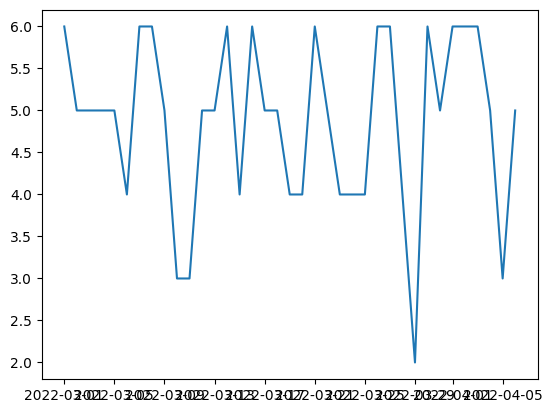

In [6]:
import matplotlib.pyplot as plt

plt.plot(lstm_df["Order_Date"], lstm_df["Num_Of_Orders"])